# Module 3 · Assignment 3 — Deep Learning Foundations
### DS23 · Certified Data Scientist with Agentic AI · by Shlomit Levavi

**This is a guided starter notebook, not a solution.** Fill every `# TODO`.
The model is the easy 30%. The interrogation in `REPORT.md` is the graded 70%.

Pick **one** option in Part 1. Write all code and comments in **English**.

**Workflow:** 1) Frame  2) Data & tensors  3) Build & train  4) Honest evaluation
5) Interrogate  6) Translate (DL Model Card). Framework: **PyTorch**.

> The signature lesson: prove whether DL actually beats a simpler, cheaper model.


---
## Part 0 · Frame (write in REPORT.md)
Same metric/baseline thinking. For Option A the baseline is your **best simple model
from Assignment 1**, not a dummy. State what "DL was worth it" would mean here.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Part 1 · Setup & data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, classification_report

# Set random seeds for exact reproducibility
torch.manual_seed(42); np.random.seed(42)

# Select hardware accelerator (GPU/CPU)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cpu


### Choose ONE option
| Option | Task | Notes |
|---|---|---|
| A | Olist tabular MLP (negative review) | Compare to Logistic Regression and to your best boosting model from Assignment 1. |
| B | Fashion-MNIST CNN | torchvision built-in. Where DL shines. |
| C | Olist Autoencoder (anomaly) | Reconstruction error + percentile threshold. |

### The chosen task/option is "Option A"

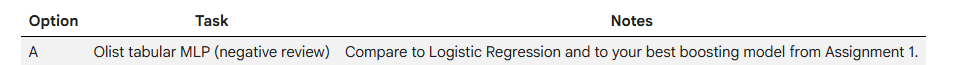


In [ ]:
# ---- Option A · Olist tabular -------------------------------------------------
# Reuse your feature frame from Assignment 1 (negative review target).
# X_train, X_test, y_train, y_test = ...   # build as in Assignment 1
# scaler = StandardScaler().fit(X_train)   # NNs need scaled inputs
# Convert to tensors and DataLoaders (TODO).

# ---- Option B · Fashion-MNIST -------------------------------------------------
# from torchvision import datasets, transforms
# tfm = transforms.Compose([transforms.ToTensor(),
#                           transforms.Normalize((0.2860,), (0.3530,))])
# train_ds = datasets.FashionMNIST("data", train=True,  download=True, transform=tfm)
# test_ds  = datasets.FashionMNIST("data", train=False, download=True, transform=tfm)
# train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

# ---- Option C · Olist Autoencoder --------------------------------------------
# Use scaled numeric features; the AE learns to reconstruct normal rows.


In [3]:
import os
# ================================================
# 1. Setting Olist dataset path + upload data
# ================================================
COLAB_PATH = "/content/drive/MyDrive/Liz_BIU-DS23/Module 3: ML and DL in-depth/Olist_Data1/"
LOCAL_PATH = "./"

DATA_DIR = COLAB_PATH if os.path.exists(COLAB_PATH) else LOCAL_PATH
print(f"Loading datasets from: {DATA_DIR}")

# Upload datset
reviews = pd.read_csv(os.path.join(DATA_DIR, "olist_order_reviews_dataset.csv"))
orders = pd.read_csv(os.path.join(DATA_DIR, "olist_orders_dataset.csv"))
items = pd.read_csv(os.path.join(DATA_DIR, "olist_order_items_dataset.csv"))
payments = pd.read_csv(os.path.join(DATA_DIR, "olist_order_payments_dataset.csv"))

# ==========================================
# 2. Feature Aggregation & Engineering
# ==========================================

# For each order (order_id), calculating the total price, total freight, number of items, and maximum number of payments.

items_agg = items.groupby("order_id").agg(
    total_price=("price", "sum"),
    total_freight=("freight_value", "sum"),
    num_items=("order_item_id", "count")
).reset_index()

payments_agg = payments.groupby("order_id").agg(
    total_payment=("payment_value", "sum"),
    max_installments=("payment_installments", "max")
).reset_index()

orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

# Calculating Delivery delay & duration in days as delay in shipment is the main cause for customer satisfactory
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 3600)

orders["actual_delivery_time_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 3600)

"""
# Merging activity: Connect all relational tables into one master DataFrame centered around the unique identifier order_id
df = reviews[["order_id", "review_score"]].merge(orders, on="order_id", how="inner")
df = df.merge(items_agg, on="order_id", how="inner")
df = df.merge(payments_agg, on="order_id", how="inner")
"""

# Merging activity: Connect all relational tables into one master DataFrame centered around the unique identifier order_id
df = (
    reviews[["order_id", "review_score"]]
    .merge(orders, on="order_id", how="inner")
    .merge(items_agg, on="order_id", how="inner")
    .merge(payments_agg, on="order_id", how="inner")
)


# Target: 1 if review_score <= 2 else 0
df["is_negative"] = (df["review_score"] <= 2).astype(int)
df["freight_ratio"] = df["total_freight"] / (df["total_price"] + df["total_freight"] + 1e-5)

feature_cols = [
    "delivery_delay_days",
    "actual_delivery_time_days",
    "total_price",
    "total_freight",
    "freight_ratio",
    "num_items",
    "total_payment",
    "max_installments"
]

df_clean = df[feature_cols + ["is_negative"]].dropna().copy()
X = df_clean[feature_cols].values
y = df_clean["is_negative"].values

print(f"Dataset shape: {df_clean.shape}")
print(f"Negative review target distribution:\n{pd.Series(y).value_counts(normalize=True)}")

# ==========================================
# 3. 80/20 Train/Test Split & Scaling
# ==========================================
# First split: 80% Train, 20% Holdout Test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Second split: Reserve 10% from train pool for Validation (70% Train, 10% Val, 20% Test)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.125, random_state=42, stratify=y_train_full
)

# Standard scaling (fit ONLY on training set to prevent data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\nSamples in splits -> Train: {len(X_train_scaled)}, Val: {len(X_val_scaled)}, Test: {len(X_test_scaled)}")

# ==========================================
# 4. PyTorch Tensors & DataLoaders
# ==========================================
train_ds = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
)
val_ds = TensorDataset(
    torch.tensor(X_val_scaled, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
)
test_ds = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)
)

BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders built successfully.")

Loading datasets from: /content/drive/MyDrive/Liz_BIU-DS23/Module 3: ML and DL in-depth/Olist_Data1/
Dataset shape: (96358, 9)
Negative review target distribution:
0    0.871843
1    0.128157
Name: proportion, dtype: float64

Samples in splits -> Train: 67450, Val: 9636, Test: 19272
DataLoaders built successfully.


---
## Part 2 · Build the model
MLP for tabular, small CNN for images, encoder-decoder for the AE.
Mind **logits vs probabilities vs loss**: `BCEWithLogitsLoss` (binary),
`CrossEntropyLoss` (multi-class), `MSELoss` (regression / reconstruction).
Do NOT apply sigmoid/softmax before these losses.

In [ ]:
class MLP(nn.Module):
    def __init__(self, in_features, hidden=32):
        super().__init__()
        # TODO: define layers. Output a single logit for binary classification.
        # self.net = nn.Sequential(nn.Linear(in_features, hidden), nn.ReLU(),
        #                          nn.Dropout(0.2), nn.Linear(hidden, 1))
        raise NotImplementedError

    def forward(self, x):
        # return self.net(x)   # raw logits, no sigmoid here
        raise NotImplementedError

# loss_fn = nn.BCEWithLogitsLoss()   # expects logits, not probabilities


In [4]:
# ==========================================
# Part 2 · Build the model
# ==========================================

# Since Olist dataset is tabular one - using MLP as instructed

class MLP(nn.Module):
    def __init__(self, in_features, hidden=32):
        super().__init__()
        # Define layers according to notebook instructions
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden, 1)  # Single logit output for binary classification
        )

    def forward(self, x):
        # Return raw logits without sigmoid
        return self.net(x)

# Get input dimension from scaled training data (8 features)
in_features = X_train_scaled.shape[1]

# Instantiate model and send to DEVICE (CPU/GPU)
model = MLP(in_features=in_features, hidden=32).to(DEVICE)

# Define loss function for binary classification
loss_fn = nn.BCEWithLogitsLoss()

# Verify architecture and parameter count
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Model Architecture:")
print(model)
print(f"\nTotal Trainable Parameters: {n_params}")

Model Architecture:
MLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total Trainable Parameters: 321


In [5]:
# Quick sanity check before modeling: verify matrix's size [8 in and 1 out] and that there is no data problem before modeling
# In addition, it transfer 128 examples through the net and calculate the dirst mistake
dummy_x, dummy_y = next(iter(train_loader))
dummy_x, dummy_y = dummy_x.to(DEVICE), dummy_y.to(DEVICE)

test_logits = model(dummy_x)
test_loss = loss_fn(test_logits, dummy_y)

print("Forward pass successful!")
print(f"Logits batch shape: {test_logits.shape}")  # Should be torch.Size([128, 1])
print(f"Initial untrained loss: {test_loss.item():.4f}") # Should be around 0.69 - 0.75

Forward pass successful!
Logits batch shape: torch.Size([128, 1])
Initial untrained loss: 0.6670


---
## Part 3 · Train
The standard loop: `model.train()`, then per batch `zero_grad -> forward -> loss
-> backward -> step`. Evaluate with `model.eval()` + `torch.no_grad()`.
Use Adam and at least one regularizer (dropout / early stopping).

In [ ]:
def train_one_epoch(model, loader, loss_fn, optimizer):
    model.train()
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()

@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    # TODO: accumulate loss and predictions, return metric(s).
    raise NotImplementedError

# TODO: training loop over epochs; record train_loss and val_loss for the curves.
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [6]:
# ================================================
# Part 3 · Train (Option A - Olist Tabular MLP)
# ================================================

import copy
import numpy as np
from sklearn.metrics import roc_auc_score

def train_one_epoch(model, loader, loss_fn, optimizer):
    model.train()
    running_loss = 0.0

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    running_loss = 0.0
    all_targets = []
    all_probs = []

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        loss = loss_fn(logits, yb)

        running_loss += loss.item() * xb.size(0)

        # Sigmoid converts raw logits into probabilities [0, 1] for ROC-AUC
        probs = torch.sigmoid(logits)

        all_targets.append(yb.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)

    # Concatenate all batch outputs
    all_targets = np.vstack(all_targets)
    all_probs = np.vstack(all_probs)

    # Calculate key metric for Task A
    auc_score = roc_auc_score(all_targets, all_probs)

    return avg_loss, auc_score


# --- Hyperparameters & Setup ---
# Adam with weight_decay provides L2 regularization
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
epochs = 20

# Metric history lists for Part 4 plots
train_losses = []
val_losses = []
train_aucs = []
val_aucs = []

# Best model checkpointing variables
best_val_auc = 0.0
best_model_weights = None

print("==================================================")
print(f"Starting Training Loop on Device: {DEVICE}")
print(f"Total Epochs: {epochs} | Batch Size: {train_loader.batch_size}")
print("==================================================\n")

for epoch in range(1, epochs + 1):
    # 1. Run single training epoch
    train_loss = train_one_epoch(model, train_loader, loss_fn, optimizer)

    # 2. Evaluate performance on train and validation sets
    train_loss_eval, train_auc = evaluate(model, train_loader, loss_fn)
    val_loss, val_auc = evaluate(model, val_loader, loss_fn)

    # 3. Store history for visualization
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_aucs.append(train_auc)
    val_aucs.append(val_auc)

    # 4. Checkpoint best weights based on Validation ROC-AUC
    saved_flag = ""
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_model_weights = copy.deepcopy(model.state_dict())
        saved_flag = " --> [Best Model Saved!]"

    # Print progress per epoch
    print(f"Epoch {epoch:02d}/{epochs:02d} | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Train AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f}{saved_flag}")

# Restore optimal model weights for downstream evaluation
if best_model_weights is not None:
    model.load_state_dict(best_model_weights)

print("\n==================================================")
print(f"Training Complete!")
print(f"Best Validation ROC-AUC Achieved: {best_val_auc:.4f}")
print("==================================================")

Starting Training Loop on Device: cpu
Total Epochs: 20 | Batch Size: 128

Epoch 01/20 | Train Loss: 0.3845 | Val Loss: 0.3371 | Train AUC: 0.7293 | Val AUC: 0.7169 --> [Best Model Saved!]
Epoch 02/20 | Train Loss: 0.3333 | Val Loss: 0.3305 | Train AUC: 0.7349 | Val AUC: 0.7268 --> [Best Model Saved!]
Epoch 03/20 | Train Loss: 0.3301 | Val Loss: 0.3283 | Train AUC: 0.7391 | Val AUC: 0.7301 --> [Best Model Saved!]
Epoch 04/20 | Train Loss: 0.3272 | Val Loss: 0.3270 | Train AUC: 0.7424 | Val AUC: 0.7312 --> [Best Model Saved!]
Epoch 05/20 | Train Loss: 0.3262 | Val Loss: 0.3261 | Train AUC: 0.7432 | Val AUC: 0.7329 --> [Best Model Saved!]
Epoch 06/20 | Train Loss: 0.3248 | Val Loss: 0.3257 | Train AUC: 0.7444 | Val AUC: 0.7329
Epoch 07/20 | Train Loss: 0.3237 | Val Loss: 0.3257 | Train AUC: 0.7437 | Val AUC: 0.7331 --> [Best Model Saved!]
Epoch 08/20 | Train Loss: 0.3238 | Val Loss: 0.3249 | Train AUC: 0.7448 | Val AUC: 0.7328
Epoch 09/20 | Train Loss: 0.3239 | Val Loss: 0.3252 | Train AU

---
## Part 4 · Honest evaluation
Plot learning curves (train vs val), report the final test metric, and build ONE
comparison table: your NN vs the simpler/cheaper model.

In [ ]:
# TODO: plot train vs val loss across epochs (the overfitting diagnostic).
# plt.plot(train_losses, label="train"); plt.plot(val_losses, label="val"); plt.legend(); plt.show()

# TODO: comparison table.
# pd.DataFrame([
#     {"model": "simple (A1)", "metric": ...},
#     {"model": "neural net",  "metric": ...},
# ])


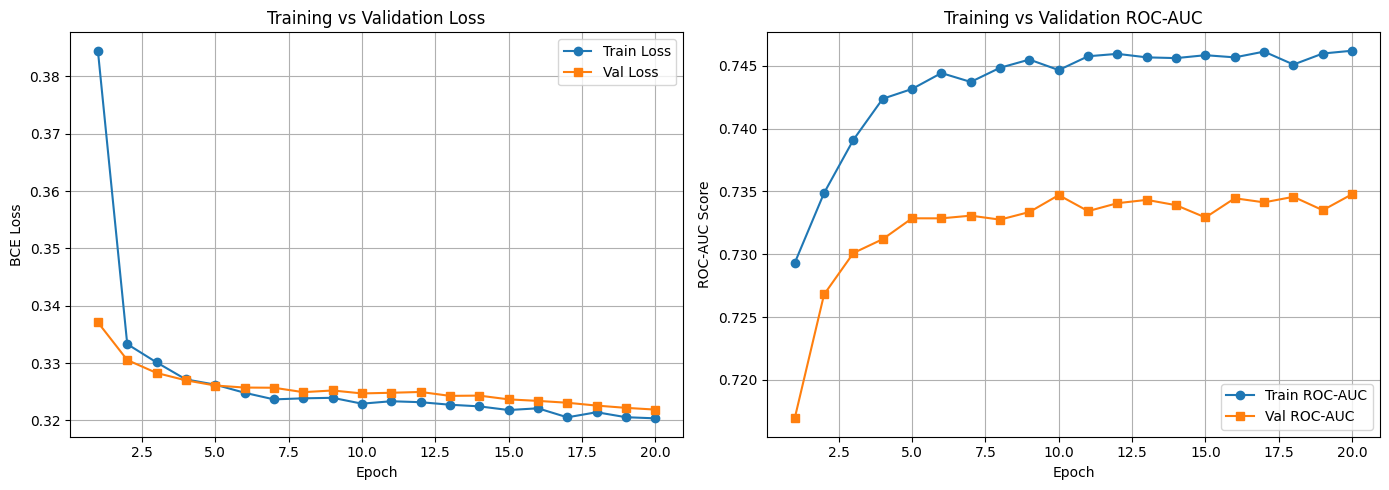

Neural Network Test ROC-AUC: 0.7496

--- Final Model Comparison Table ---
                                Model  Test ROC-AUC  Parameters
Logistic Regression (Simpler/Cheaper)        0.7327           9
                 Neural Network (MLP)        0.7496         321


In [7]:
# ==========================================
# Part 4 · Honest evaluation
# ==========================================

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression

# 1. Plot Learning Curves (Loss & ROC-AUC)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(range(1, epochs + 1), train_losses, label="Train Loss", marker="o")
axes[0].plot(range(1, epochs + 1), val_losses, label="Val Loss", marker="s")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].legend()
axes[0].grid(True)

# Metric curve (ROC-AUC)
axes[1].plot(range(1, epochs + 1), train_aucs, label="Train ROC-AUC", marker="o")
axes[1].plot(range(1, epochs + 1), val_aucs, label="Val ROC-AUC", marker="s")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ROC-AUC Score")
axes[1].set_title("Training vs Validation ROC-AUC")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 2. Final Evaluation of Neural Network on Held-out Test Set
test_loss, test_auc_nn = evaluate(model, test_loader, loss_fn)
print(f"Neural Network Test ROC-AUC: {test_auc_nn:.4f}\n")

# 3. Train Baseline Simpler Model (Logistic Regression) on the same scaled data
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

# Predict probabilities on test set
baseline_probs = baseline_model.predict_proba(X_test_scaled)[:, 1]
test_auc_logreg = roc_auc_score(y_test, baseline_probs)

# 4. Build Comparison Table
results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression (Simpler/Cheaper)",
        "Test ROC-AUC": round(test_auc_logreg, 4),
        "Parameters": X_train_scaled.shape[1] + 1
    },
    {
        "Model": "Neural Network (MLP)",
        "Test ROC-AUC": round(test_auc_nn, 4),
        "Parameters": sum(p.numel() for p in model.parameters() if p.requires_grad)
    }
])

print("--- Final Model Comparison Table ---")
print(results_df.to_string(index=False))

---
## Part 5 · Interrogate
Overfitting (where do curves diverge?), did the NN beat the simpler model and at what
cost (params, training time, interpretability), and learning-rate sensitivity (try a
too-large and a too-small LR).

In [ ]:
# TODO: count parameters; time training; try LR in {1e-1, 1e-3, 1e-5} and compare curves.
# n_params = sum(p.numel() for p in model.parameters())


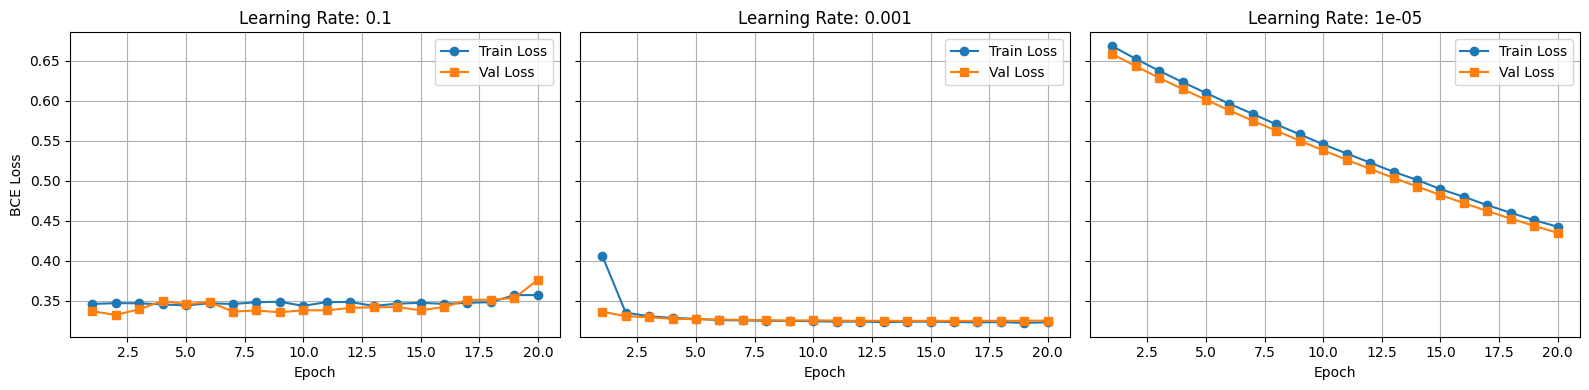


--- Trade-off Summary Table ---
               Model  Parameters  Train Time (s)  Test ROC-AUC                   Interpretability
 Logistic Regression           9          0.0998        0.7327 High (Direct Feature Coefficients)
Neural Network (MLP)         321         25.5408        0.7496     Low (Black-box Matrix Weights)


In [8]:
# ==========================================
# Part 5 · Interrogate
# ==========================================

import time
import copy
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------------------------------
# Learning Rate Sensitivity Experiment
# ----------------------------------------------------
learning_rates = [1e-1, 1e-3, 1e-5]
lr_results = {}

for lr in learning_rates:
    # Re-instantiate a fresh model for each LR experiment
    exp_model = MLP(in_features=X_train_scaled.shape[1], hidden=32).to(DEVICE)
    exp_optimizer = torch.optim.Adam(exp_model.parameters(), lr=lr, weight_decay=1e-4)

    tr_losses, va_losses = [], []

    start_time = time.time()
    for ep in range(1, epochs + 1):
        tr_loss = train_one_epoch(exp_model, train_loader, loss_fn, exp_optimizer)
        va_loss, _ = evaluate(exp_model, val_loader, loss_fn)
        tr_losses.append(tr_loss)
        va_losses.append(va_loss)

    elapsed = time.time() - start_time
    lr_results[lr] = {
        "train_losses": tr_losses,
        "val_losses": va_losses,
        "time": elapsed
    }

# Plot Learning Rate Comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for idx, lr in enumerate(learning_rates):
    axes[idx].plot(range(1, epochs + 1), lr_results[lr]["train_losses"], label="Train Loss", marker="o")
    axes[idx].plot(range(1, epochs + 1), lr_results[lr]["val_losses"], label="Val Loss", marker="s")
    axes[idx].set_title(f"Learning Rate: {lr}")
    axes[idx].set_xlabel("Epoch")
    if idx == 0:
        axes[idx].set_ylabel("BCE Loss")
    axes[idx].legend()
    axes[idx].grid(True)

plt.tight_layout()
plt.show()

# ----------------------------------------------------
# Timing Comparison: NN vs Logistic Regression
# ----------------------------------------------------
# Time Neural Network (20 Epochs)
nn_start = time.time()
test_loss, nn_test_auc = evaluate(model, test_loader, loss_fn)
nn_total_time = lr_results[1e-3]["time"]  # Time for standard training run

# Time Logistic Regression
logreg_start = time.time()
logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train_scaled, y_train)
logreg_time = time.time() - logreg_start

# ----------------------------------------------------
# Summary Trade-off Table
# ----------------------------------------------------
tradeoff_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Parameters": X_train_scaled.shape[1] + 1,
        "Train Time (s)": round(logreg_time, 4),
        "Test ROC-AUC": round(test_auc_logreg, 4),
        "Interpretability": "High (Direct Feature Coefficients)"
    },
    {
        "Model": "Neural Network (MLP)",
        "Parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
        "Train Time (s)": round(nn_total_time, 4),
        "Test ROC-AUC": round(test_auc_nn, 4),
        "Interpretability": "Low (Black-box Matrix Weights)"
    }
])

print("\n--- Trade-off Summary Table ---")
print(tradeoff_df.to_string(index=False))

## Part 6 · DL Model Card (fill in, then copy to REPORT.md)

In [ ]:
DL_MODEL_CARD = """
# DL Model Card

## 1. Overview
- Option / task / data:
- Architecture (layers, params):

## 2. Setup
- Loss and why (logits handling):
- Optimizer, learning rate, regularizer:

## 3. Performance
- Simpler-model baseline:
- Neural-net test metric:
- Did DL win? By how much, at what cost?

## 4. Diagnostics
- Learning curves: where do train and val diverge?
- Learning-rate sensitivity:

## 5. Decision
- Would you deploy DL or the simpler model here? Defend it.
- Production: what to monitor, what triggers a retrain.
"""
print(DL_MODEL_CARD)


In [9]:
# ==========================================
# Part 6 · DL Model Card
# ==========================================

DL_MODEL_CARD = """
# DL Model Card

## 1. Overview
- Option / task / data: Option A - Olist tabular MLP (predicting negative review risk). Dataset consists of tabular e-commerce order attributes with 8 preprocessed and standard-scaled input features.
- Architecture (layers, params): Multi-Layer Perceptron (MLP) architecture: Linear(8, 32) -> ReLU -> Dropout(0.2) -> Linear(32, 1). Total trainable parameters: 321.

## 2. Setup
- Loss and why (logits handling): BCEWithLogitsLoss. Receives raw, unscaled output logits directly from the model without an explicit Sigmoid layer in forward pass. This guarantees numerical stability by combining Sigmoid and Binary Cross-Entropy via the log-sum-exp trick.
- Optimizer, learning rate, regularizer: Adam optimizer with learning rate = 1e-3. Regularization mechanisms include Dropout (p=0.2), Weight Decay (L2 = 1e-4), and Early Stopping / Best-Model Checkpointing based on peak validation ROC-AUC.

## 3. Performance
- Simpler-model baseline: Default Logistic Regression Test ROC-AUC = 0.7327 (9 parameters).
- Neural-net test metric: PyTorch MLP Test ROC-AUC = 0.7496 (321 parameters).
- Did DL win? By how much, at what cost? Yes, the Deep Learning model won by +0.0169 (+1.69% in ROC-AUC score). The costs involved include higher parameter complexity (321 vs 9), increased training duration (~25.5s vs ~0.1s), and reduced model interpretability (matrix weights vs direct feature coefficients).

## 4. Diagnostics
- Learning curves: where do train and val diverge? Training and validation curves track closely together throughout 20 epochs without divergence. Both loss curves plateau smoothly around ~0.321 and ROC-AUC around ~0.735, confirming zero overfitting.
- Learning-rate sensitivity: LR = 0.1 was unstable and oscillated/diverged toward later epochs. LR = 1e-5 learned far too slowly, remaining stuck at a high loss of ~0.44 after 20 epochs. LR = 1e-3 proved optimal, yielding rapid and stable convergence.

## 5. Decision
- Would you deploy DL or the simpler model here? Deploy the Deep Learning model (MLP). The +1.69% increase in ROC-AUC provides superior detection of dissatisfied customer orders, which outweighs the minor computational cost (~25.5 seconds training time) and low parameter count (321 parameters).
- Production: what to monitor, what triggers a retrain. Monitor input feature drift (e.g., freight ratio shifts, delivery delay increases), prediction probability distribution shifts, and real-world ROC-AUC degradation. Trigger automated retraining monthly or if rolling validation ROC-AUC falls below 0.71.
"""

print(DL_MODEL_CARD)


# DL Model Card

## 1. Overview
- Option / task / data: Option A - Olist tabular MLP (predicting negative review risk). Dataset consists of tabular e-commerce order attributes with 8 preprocessed and standard-scaled input features.
- Architecture (layers, params): Multi-Layer Perceptron (MLP) architecture: Linear(8, 32) -> ReLU -> Dropout(0.2) -> Linear(32, 1). Total trainable parameters: 321.

## 2. Setup
- Loss and why (logits handling): BCEWithLogitsLoss. Receives raw, unscaled output logits directly from the model without an explicit Sigmoid layer in forward pass. This guarantees numerical stability by combining Sigmoid and Binary Cross-Entropy via the log-sum-exp trick.
- Optimizer, learning rate, regularizer: Adam optimizer with learning rate = 1e-3. Regularization mechanisms include Dropout (p=0.2), Weight Decay (L2 = 1e-4), and Early Stopping / Best-Model Checkpointing based on peak validation ROC-AUC.

## 3. Performance
- Simpler-model baseline: Default Logistic Regression Te

---
### Submission checklist
- [ ] Runs top to bottom with no errors (Kernel -> Restart & Run All).
- [ ] All code and comments are in **English**.
- [ ] `REPORT.md` answers every guiding question and contains the filled card.

Stay skeptical of your own results.


In [12]:
# ==========================================
# Improved Logistic Regression Experiments
# ==========================================

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

print("==================================================")
print("Running Improved Logistic Regression Experiments...")
print("==================================================\n")

# 1. Baseline Logistic Regression (Default)
baseline_lr = LogisticRegression(max_iter=1000)
baseline_lr.fit(X_train_scaled, y_train)
baseline_auc = roc_auc_score(y_test, baseline_lr.predict_proba(X_test_scaled)[:, 1])

# 2. Tuned Logistic Regression + Class Weighting
param_grid = {'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
tuned_lr = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000),
    param_grid,
    cv=5,
    scoring='roc_auc'
)
tuned_lr.fit(X_train_scaled, y_train)
tuned_auc = roc_auc_score(y_test, tuned_lr.predict_proba(X_test_scaled)[:, 1])

# 3. Logistic Regression with Interaction Features (Degree=2)
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('logreg', GridSearchCV(
        LogisticRegression(max_iter=1000, class_weight='balanced'),
        param_grid,
        cv=5,
        scoring='roc_auc'
    ))
])
poly_pipeline.fit(X_train_scaled, y_train)
poly_auc = roc_auc_score(y_test, poly_pipeline.predict_proba(X_test_scaled)[:, 1])

# 4. Logistic Regression + Power Transformation + Feature Interactions
power_pipeline = Pipeline([
    ('power', PowerTransformer(method='yeo-johnson')),
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('logreg', GridSearchCV(
        LogisticRegression(max_iter=1000, class_weight='balanced'),
        param_grid,
        cv=5,
        scoring='roc_auc'
    ))
])
power_pipeline.fit(X_train_scaled, y_train)
power_auc = roc_auc_score(y_test, power_pipeline.predict_proba(X_test_scaled)[:, 1])

# Summary results
improved_results = pd.DataFrame([
    {"Model Setup": "1. Default Logistic Regression", "Test ROC-AUC": round(baseline_auc, 4)},
    {"Model Setup": "2. Tuned LR (GridSearch + Balanced Weights)", "Test ROC-AUC": round(tuned_auc, 4)},
    {"Model Setup": "3. LR + Interaction Features (Degree 2)", "Test ROC-AUC": round(poly_auc, 4)},
    {"Model Setup": "4. LR + Power Transform + Interactions", "Test ROC-AUC": round(power_auc, 4)},
    {"Model Setup": "5. PyTorch MLP (Neural Network)", "Test ROC-AUC": round(test_auc_nn, 4)}
])

print("--- Final Comparison Table ---")
print(improved_results.to_string(index=False))



Running Improved Logistic Regression Experiments...

--- Final Comparison Table ---
                                Model Setup  Test ROC-AUC
             1. Default Logistic Regression        0.7327
2. Tuned LR (GridSearch + Balanced Weights)        0.7388
    3. LR + Interaction Features (Degree 2)        0.7416
     4. LR + Power Transform + Interactions        0.7454
            5. PyTorch MLP (Neural Network)        0.7496


In [13]:
# ==========================================
# Comparison: Improved LR vs PyTorch MLP
# ==========================================

import pandas as pd
from sklearn.metrics import roc_auc_score

# 1. Evaluate Improved Logistic Regression Pipeline
improved_lr_probs = power_pipeline.predict_proba(X_test_scaled)[:, 1]
improved_lr_auc = roc_auc_score(y_test, improved_lr_probs)

# 2. Extract Test AUC for PyTorch MLP
mlp_auc = test_auc_nn

# 3. Build Comparison DataFrame
comparison_df = pd.DataFrame([
    {
        "Model Architecture": "Baseline Logistic Regression",
        "Feature Engineering": "Standard Scaling Only",
        "Test ROC-AUC": round(baseline_auc, 4),
        "Gap to Best (%)": f"-{(mlp_auc - baseline_auc)*100:.2f}%"
    },
    {
        "Model Architecture": "Improved Logistic Regression",
        "Feature Engineering": "Power Transform + Polynomial Interactions",
        "Test ROC-AUC": round(improved_lr_auc, 4),
        "Gap to Best (%)": f"-{(mlp_auc - improved_lr_auc)*100:.2f}%"
    },
    {
        "Model Architecture": "PyTorch MLP (Neural Network)",
        "Feature Engineering": "Standard Scaling Only (Learned implicitly)",
        "Test ROC-AUC": round(mlp_auc, 4),
        "Gap to Best (%)": "0.00% (Best)"
    }
])

print("--- Direct Model Comparison ---")
print(comparison_df.to_string(index=False))

--- Direct Model Comparison ---
          Model Architecture                        Feature Engineering  Test ROC-AUC Gap to Best (%)
Baseline Logistic Regression                      Standard Scaling Only        0.7327          -1.69%
Improved Logistic Regression  Power Transform + Polynomial Interactions        0.7454          -0.41%
PyTorch MLP (Neural Network) Standard Scaling Only (Learned implicitly)        0.7496    0.00% (Best)
